<a href="https://colab.research.google.com/github/mariaclaraseixa/stochastic-processes-f1/blob/main/bahrein2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Teoria das Filas + Cadeias de Markov — GP Bahrein 2022
# Processos Estocásticos — UFSC Joinville
# ============================================================

# ── Instalação (Colab) ──────────────────────────────────────
!pip install fastf1 -q

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
from scipy.stats import expon
from math import factorial
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("cache_f1", exist_ok=True)
fastf1.Cache.enable_cache("cache_f1")


events      WARNING 	Correcting user input 'Bahrein' to 'Bahrain Grand Prix'
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_da

Tempo médio de volta normal: 99.67 s
Pit stops detectados: 39
   PitDriver  LapNumber  LapTime_s  ServiceTime_s             Team CompoundBefore CompoundAfter
0        ALB       14.0    121.075      21.401899         Williams           SOFT        MEDIUM
1        ALO       12.0    120.053      20.379899           Alpine           SOFT        MEDIUM
2        ALO       26.0    120.922      21.248899           Alpine         MEDIUM          HARD
3        ALO       43.0    117.366      17.692899           Alpine           HARD          SOFT
4        BOT       15.0    120.669      20.995899       Alfa Romeo           SOFT        MEDIUM
5        BOT       37.0    118.899      19.225899       Alfa Romeo         MEDIUM        MEDIUM
6        GAS       15.0    121.397      21.723899       AlphaTauri           SOFT        MEDIUM
7        GAS       33.0    120.808      21.134899       AlphaTauri         MEDIUM          HARD
8        HAM       12.0    123.697      24.023899         Mercedes        

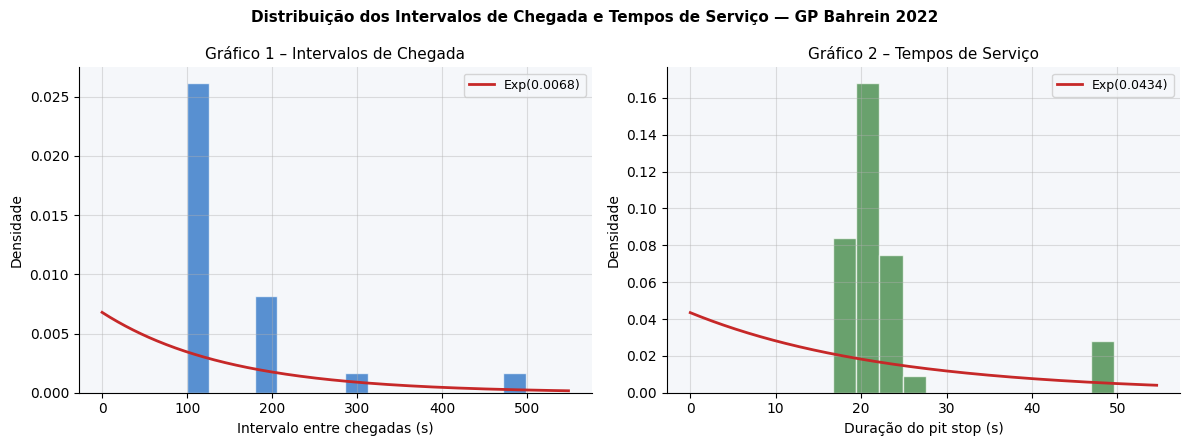

Salvo: distribuicoes.png


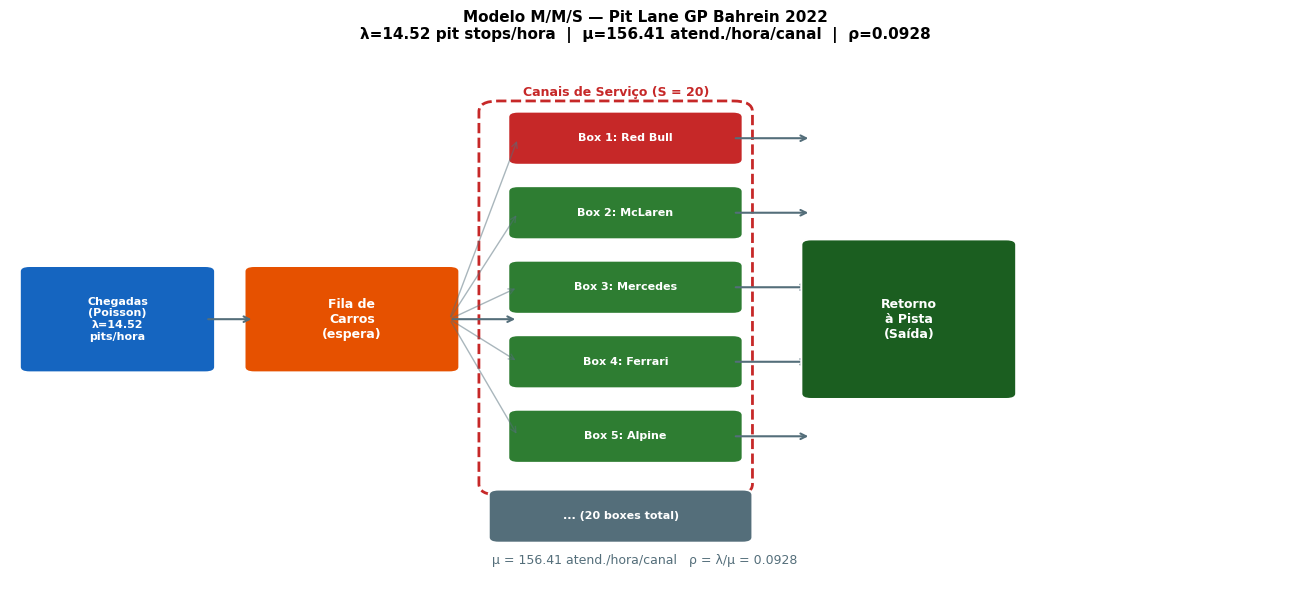

Salvo: diagrama_sistema_filas.png


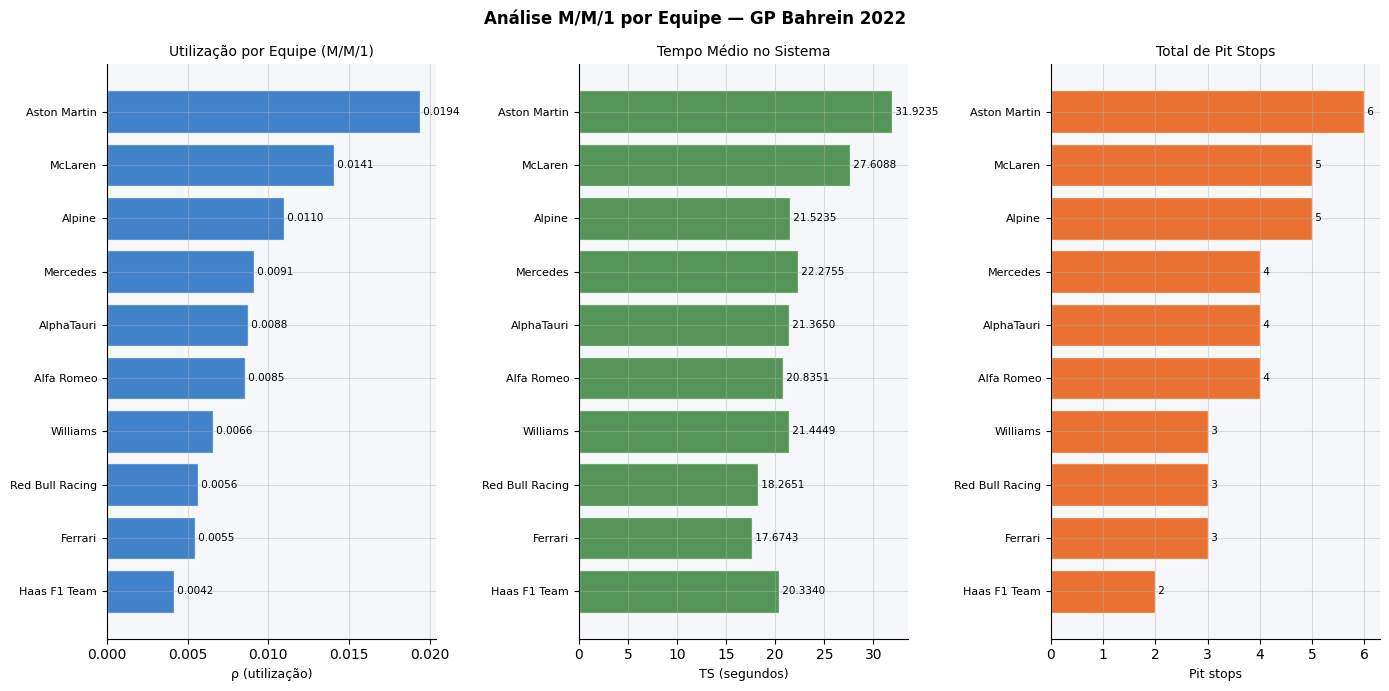

Salvo: mm1_por_equipe.png


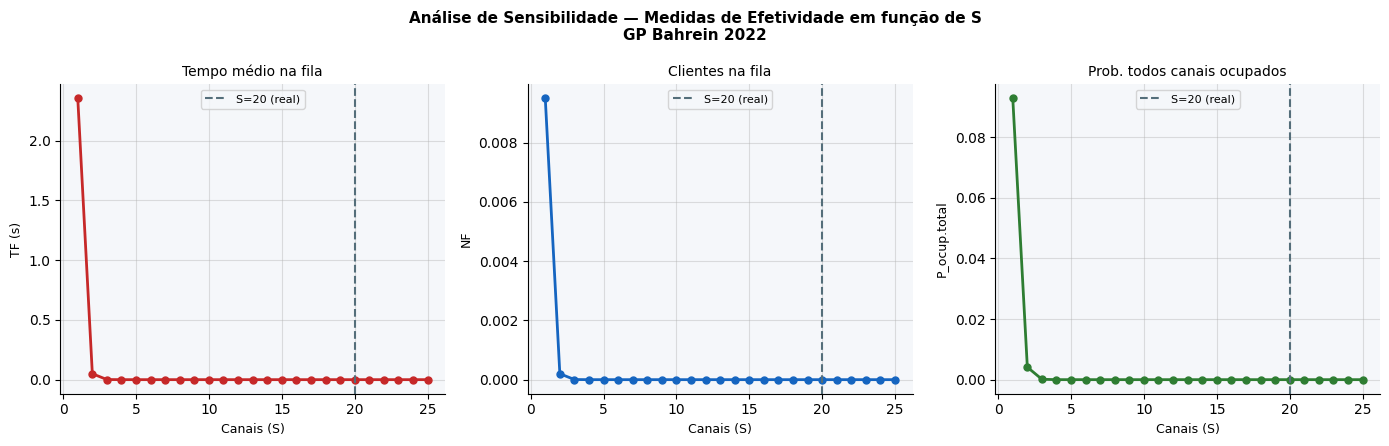

Salvo: sensibilidade_canais.png


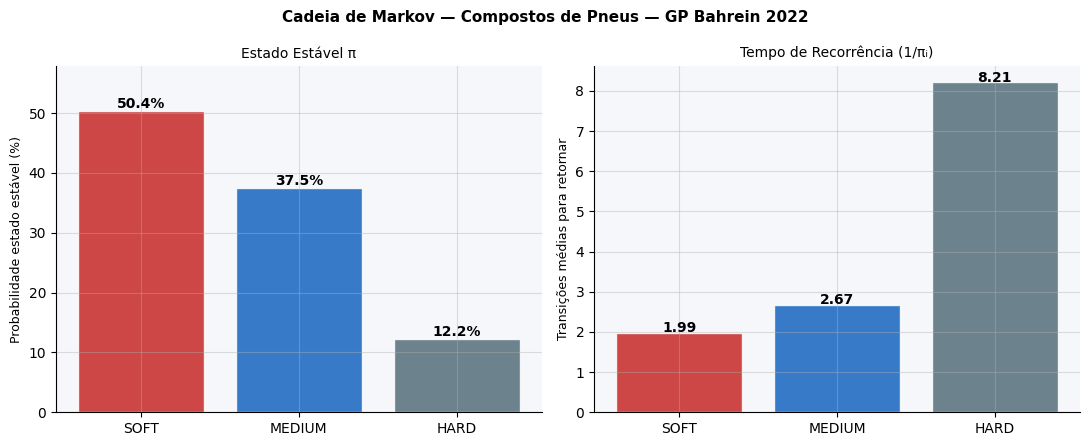

Salvo: markov_resultados.png


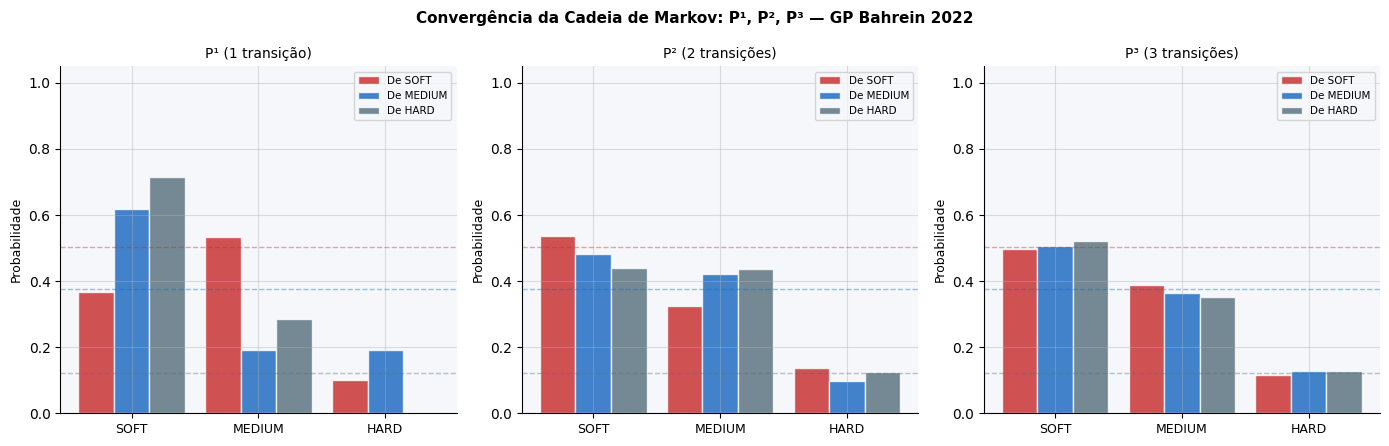

Salvo: markov_convergencia.png

✅ Concluído. Arquivos gerados:
  distribuicoes.png | diagrama_sistema_filas.png | mm1_por_equipe.png
  sensibilidade_canais.png | markov_resultados.png | markov_convergencia.png


In [ ]:
# ============================================================
# Teoria das Filas + Cadeias de Markov — GP Bahrein 2022
# Processos Estocásticos — UFSC Joinville
# ============================================================

# ── Instalação (Colab) ──────────────────────────────────────
!pip install fastf1 -q

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
from scipy.stats import expon
from math import factorial
import os
import warnings
warnings.filterwarnings("ignore")

os.makedirs("cache_f1", exist_ok=True)
fastf1.Cache.enable_cache("cache_f1")

# ============================================================
# 1. COLETA E PRÉ-PROCESSAMENTO
# ============================================================

session = fastf1.get_session(2022, "Bahrein", "R")
session.load(telemetry=False, weather=False)

laps = session.laps.copy()
laps = laps[laps["LapTime"].notna()].copy()
laps["LapTime_s"] = laps["LapTime"].dt.total_seconds()

# Tempo médio de volta normal (IQR filter)
lap_times_all = laps["LapTime_s"]
q1, q3 = lap_times_all.quantile(0.25), lap_times_all.quantile(0.75)
normal_mask = (lap_times_all >= q1 - 1.5*(q3-q1)) & (lap_times_all <= q3 + 1.5*(q3-q1))
mean_normal_lap = lap_times_all[normal_mask].mean()
print(f"Tempo médio de volta normal: {mean_normal_lap:.2f} s")

# Detectar pit stops via TyreLife (queda: >3 → ≤2)
laps_sorted = laps.sort_values(["Driver", "LapNumber"]).copy()
pit_laps = []

for driver, grp in laps_sorted.groupby("Driver"):
    grp = grp.reset_index(drop=True)
    for i in range(1, len(grp)):
        prev_tl = grp.loc[i-1, "TyreLife"]
        curr_tl = grp.loc[i,   "TyreLife"]
        if pd.notna(prev_tl) and pd.notna(curr_tl):
            if prev_tl > 3 and curr_tl <= 2:
                lap_row = grp.loc[i].copy()
                lap_row["PitDriver"] = driver
                # guarda o composto ANTERIOR (stint que terminou) e o NOVO
                lap_row["CompoundBefore"] = grp.loc[i-1, "Compound"]
                lap_row["CompoundAfter"]  = grp.loc[i,   "Compound"]
                pit_laps.append(lap_row)

pit_df = pd.DataFrame(pit_laps)
pit_df["ServiceTime_s"] = pit_df["LapTime_s"] - mean_normal_lap
pit_df = pit_df[(pit_df["ServiceTime_s"] > 10) & (pit_df["ServiceTime_s"] < 120)].copy()
print(f"Pit stops detectados: {len(pit_df)}")
print(pit_df[["PitDriver","LapNumber","LapTime_s","ServiceTime_s",
              "Team","CompoundBefore","CompoundAfter"]].to_string())

# ============================================================
# 2. JANELA OPERACIONAL
# ============================================================
racing_laps = laps[laps["LapNumber"] >= 1].copy()
T_corrida_s = racing_laps["Time"].max().total_seconds()
T_corrida_h = T_corrida_s / 3600
print(f"\nJanela operacional: {T_corrida_s/60:.1f} min ({T_corrida_h:.4f} h)")
# ============================================================
# 3. PARÂMETROS M/M/S — PIT LANE COMPLETO
# ============================================================

n_pitstops = len(pit_df)
lam = n_pitstops / T_corrida_h
mu  = 3600 / pit_df["ServiceTime_s"].mean()
S   = 20
rho = lam / mu

print(f"\n{'='*50}")
print("PARÂMETROS M/M/S")
print(f"{'='*50}")
print(f"  Total pit stops    : {n_pitstops}")
print(f"  Janela (h)         : {T_corrida_h:.4f}")
print(f"  λ (pit stops/h)    : {lam:.4f}")
print(f"  μ (atend/h/canal)  : {mu:.4f}")
print(f"  1/μ (s)            : {3600/mu:.2f}")
print(f"  S (canais)         : {S}")
print(f"  ρ = λ/μ            : {rho:.4f}")
print(f"  Cond. estab. λ<μS  : {lam:.2f} < {mu*S:.2f} → {lam < mu*S}")

# ---- Funções M/M/S ----------------------------------------

def mms_P0(lam, mu, S):
    rho = lam / mu
    soma = sum(rho**j / factorial(j) for j in range(S))
    soma += rho**S / (factorial(S-1) * (S - rho))
    return 1.0 / soma

def mms_metrics(lam, mu, S):
    rho  = lam / mu
    if lam >= mu * S:
        raise ValueError(f"Sistema instável: λ={lam:.2f} ≥ μS={mu*S:.2f}")
    P0   = mms_P0(lam, mu, S)
    Pocp = (rho**S / (factorial(S-1) * (S - rho))) * P0
    NF   = (rho / (S - rho)) * Pocp
    TF   = NF / lam * 3600   # segundos
    NS   = NF + rho
    TS   = NS / lam * 3600   # segundos
    return dict(P0=P0, Pocp=Pocp, NF=NF, TF=TF, NS=NS, TS=TS, rho=rho)

m = mms_metrics(lam, mu, S)
print(f"\n{'='*50}")
print("MEDIDAS DE EFETIVIDADE — M/M/20")
print(f"{'='*50}")
for k, v in m.items():
    print(f"  {k:12s}: {v:.6f}")

# ============================================================
# 4. MODELO M/M/1 POR EQUIPE
# ============================================================

def mm1_metrics(lam_e, mu_e):
    if lam_e >= mu_e:
        return dict(rho=np.nan, NF=np.nan, NS=np.nan, TF=np.nan, TS=np.nan)
    rho_e = lam_e / mu_e
    NF_e  = lam_e**2 / (mu_e * (mu_e - lam_e))
    NS_e  = lam_e / (mu_e - lam_e)
    TF_e  = lam_e / (mu_e * (mu_e - lam_e)) * 3600
    TS_e  = 1 / (mu_e - lam_e) * 3600
    return dict(rho=rho_e, NF=NF_e, NS=NS_e, TF=TF_e, TS=TS_e)

team_results = []
for team in pit_df["Team"].dropna().unique():
    t_df = pit_df[pit_df["Team"] == team]
    n_t  = len(t_df)
    lam_t = n_t / T_corrida_h
    mu_t  = 3600 / t_df["ServiceTime_s"].mean()
    met   = mm1_metrics(lam_t, mu_t)
    team_results.append({"Team": team, "n_pits": n_t,
                          "lam": lam_t, "mu": mu_t, **met})

team_df = pd.DataFrame(team_results).sort_values("rho", ascending=False)
print(f"\n{'='*50}")
print("M/M/1 POR EQUIPE")
print(f"{'='*50}")
print(team_df[["Team","n_pits","rho","TS","NF"]].to_string(index=False))

# ============================================================
# 5. ANÁLISE DE CENÁRIOS
# ============================================================

scenarios = [
    ("Real (S=20)",             S,   lam),
    ("Safety Car (S=20)",       S,   lam * 2.5),
    ("Pit Lane Compacto (S=3)", 3,   lam),
    ("S Mínimo (S=2)",          2,   lam),
]

print(f"\n{'='*65}")
print(f"{'Cenário':<28} {'S':>3} {'λ':>7} {'ρ':>7} {'P0':>8} {'NF':>8} {'TS(s)':>8}")
print(f"{'='*65}")
for name, s_c, l_c in scenarios:
    try:
        mc = mms_metrics(l_c, mu, s_c)
        print(f"{name:<28} {s_c:>3} {l_c:>7.2f} {mc['rho']:>7.4f} "
              f"{mc['P0']:>8.4f} {mc['NF']:>8.4f} {mc['TS']:>8.2f}")
    except Exception as e:
        print(f"{name:<28} INSTÁVEL ({e})")

# ============================================================
# 6. ANÁLISE DE SENSIBILIDADE
# ============================================================

S_min_stable = int(rho) + 1
S_vals = list(range(S_min_stable, S + 6))
sens = {"NF": [], "TF": [], "Pocp": []}
for sv in S_vals:
    try:
        ms = mms_metrics(lam, mu, sv)
        sens["NF"].append(ms["NF"])
        sens["TF"].append(ms["TF"])
        sens["Pocp"].append(ms["Pocp"])
    except:
        sens["NF"].append(np.nan)
        sens["TF"].append(np.nan)
        sens["Pocp"].append(np.nan)

# ============================================================
# 7. ANÁLISE DE CUSTOS
# ============================================================

CE_unit = 11000
CA_unit =  5500
mu_star  = lam + np.sqrt(lam * CE_unit / CA_unit)
CT_atual = CE_unit * (lam / (mu - lam)) + CA_unit * mu

print(f"\n{'='*50}")
print("ANÁLISE DE CUSTOS")
print(f"{'='*50}")
print(f"  μ* (ótimo)  : {mu_star:.2f} atend/h  →  {3600/mu_star:.1f} s/pit")
print(f"  μ  (real)   : {mu:.2f} atend/h  →  {3600/mu:.1f} s/pit")
print(f"  CT atual    : R$ {CT_atual:,.2f}/h")

# ============================================================
# 8. LEI DE LITTLE
# ============================================================

print(f"\n{'='*50}")
print("VERIFICAÇÃO LEI DE LITTLE")
print(f"{'='*50}")
print(f"  NF = λ·TF : {lam * m['TF']/3600:.6f}  |  NF calculado: {m['NF']:.6f}")
print(f"  NS = λ·TS : {lam * m['TS']/3600:.6f}  |  NS calculado: {m['NS']:.6f}")

# ============================================================
# 9. CADEIA DE MARKOV — TRANSIÇÕES ENTRE PIT STOPS
#    (composto ANTES da parada → composto APÓS a parada)
# ============================================================

states = ["SOFT", "MEDIUM", "HARD"]
alias  = {"S":"SOFT","M":"MEDIUM","H":"HARD",
          "SOFT":"SOFT","MEDIUM":"MEDIUM","HARD":"HARD"}

counts = pd.DataFrame(0, index=states, columns=states)

# Para cada piloto, pegar a sequência de pit stops em ordem
# e contar transições CompoundBefore[i] → CompoundAfter[i]
# e entre pit stops consecutivos: CompoundAfter[i] → CompoundBefore[i+1]
for driver, grp in pit_df.groupby("PitDriver"):
    grp = grp.sort_values("LapNumber").reset_index(drop=True)
    for idx in range(len(grp)):
        # transição dentro do pit stop: composto saindo → composto entrando
        a = alias.get(str(grp.loc[idx, "CompoundBefore"]).upper(), None)
        b = alias.get(str(grp.loc[idx, "CompoundAfter"]).upper(), None)
        if a in states and b in states and a != b:   # só conta mudanças reais
            counts.loc[a, b] += 1

# Também conta a sequência entre pit stops consecutivos do mesmo piloto
# (stint completo: CompoundAfter[i] → CompoundBefore[i+1] — devem ser iguais,
#  mas garante consistência; a transição estratégica real é Before→After acima)

# Alternativa mais fiel ao artigo: usar somente a sequência de compostos
# em que cada pit stop usa o composto NOVO como estado atual
compound_series = []
for driver, grp in pit_df.groupby("PitDriver"):
    grp = grp.sort_values("LapNumber").reset_index(drop=True)
    # primeiro composto do piloto = CompoundBefore do 1º pit
    first_comp = alias.get(str(grp.loc[0, "CompoundBefore"]).upper(), None)
    if first_comp:
        compound_series.append(first_comp)
    for idx in range(len(grp)):
        c = alias.get(str(grp.loc[idx, "CompoundAfter"]).upper(), None)
        if c:
            compound_series.append(c)

# Reconstrói counts a partir da série de compostos
counts = pd.DataFrame(0, index=states, columns=states)
for i in range(len(compound_series) - 1):
    a, b = compound_series[i], compound_series[i+1]
    if a in states and b in states:
        counts.loc[a, b] += 1

print(f"\n{'='*50}")
print("MATRIZ DE CONTAGENS — COMPOSTOS (pit stop a pit stop)")
print(f"{'='*50}")
print(counts.to_string())

# Matriz de transição
row_sums = counts.sum(axis=1)
P = counts.div(row_sums, axis=0).fillna(0)
print(f"\nMATRIZ DE TRANSIÇÃO P:")
print(P.round(4).to_string())

# Estado estável
P_np = P.values.astype(float)
A    = np.vstack([P_np.T - np.eye(len(states)), np.ones(len(states))])
b_v  = np.zeros(len(states)+1); b_v[-1] = 1.0
pi, _, _, _ = np.linalg.lstsq(A, b_v, rcond=None)
pi = np.abs(pi) / np.abs(pi).sum()

print(f"\nESTADO ESTÁVEL π:")
for s, p in zip(states, pi):
    print(f"  π_{s:<8}: {p:.4f}  ({p*100:.1f}%)  — recorrência: {1/p:.2f} transições")

P2 = P_np @ P_np
P3 = P2 @ P_np
print(f"\nP² (2 transições):")
print(pd.DataFrame(P2, index=states, columns=states).round(4).to_string())
print(f"\nP³ (3 transições):")
print(pd.DataFrame(P3, index=states, columns=states).round(4).to_string())

# ============================================================
# 10. GRÁFICOS
# ============================================================

BLUE   = "#1565C0"
RED    = "#C62828"
GREEN  = "#2E7D32"
ORANGE = "#E65100"
GRAY   = "#546E7A"
BG     = "#F5F7FA"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": BG,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

# ── GRÁFICO 1: Distribuições ─────────────────────────────────
# Intervalos entre chegadas em segundos (usando LapNumber × lap_time como proxy)
lap_nums = sorted(pit_df["LapNumber"].tolist())
inter_arrival_s = [(lap_nums[i]-lap_nums[i-1]) * mean_normal_lap
                   for i in range(1, len(lap_nums)) if lap_nums[i] > lap_nums[i-1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Distribuição dos Intervalos de Chegada e Tempos de Serviço — GP Bahrein 2022",
             fontsize=11, fontweight="bold")

ax = axes[0]
ax.hist(inter_arrival_s, bins=15, density=True, color=BLUE, alpha=0.7, edgecolor="white")
x_ia = np.linspace(0, max(inter_arrival_s)+50, 300)
lam_ia = 1 / np.mean(inter_arrival_s)
ax.plot(x_ia, expon.pdf(x_ia, scale=1/lam_ia), color=RED, lw=2,
        label=f"Exp({lam_ia:.4f})")
ax.set_xlabel("Intervalo entre chegadas (s)")
ax.set_ylabel("Densidade")
ax.set_title("Gráfico 1 – Intervalos de Chegada")
ax.legend(fontsize=9)

ax = axes[1]
st_data = pit_df["ServiceTime_s"].values
ax.hist(st_data, bins=12, density=True, color=GREEN, alpha=0.7, edgecolor="white")
x_st  = np.linspace(0, st_data.max()+5, 300)
lam_st = 1 / np.mean(st_data)
ax.plot(x_st, expon.pdf(x_st, scale=1/lam_st), color=RED, lw=2,
        label=f"Exp({lam_st:.4f})")
ax.set_xlabel("Duração do pit stop (s)")
ax.set_ylabel("Densidade")
ax.set_title("Gráfico 2 – Tempos de Serviço")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("distribuicoes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: distribuicoes.png")





canal_colors = {
    "Red Bull":  ("#A8BEE0", "#222222"),  # azul pastel, texto escuro
    "McLaren":   ("#FFD4A8", "#222222"),  # laranja pastel
    "Mercedes":  ("#A8D8C8", "#222222"),  # verde água pastel
    "Ferrari":   ("#F4A9A8", "#222222"),  # vermelho pastel
    "Alpine":    ("#C9B8E8", "#222222"),  # roxo pastel
}

for i, (name, yc) in enumerate(zip(canal_names, canal_y_centers)):
    fc, tc = canal_colors[name]
    draw_box(ax, 5.2, yc-0.3, 2.2, 0.8, fc, f"Box {i+1}: {name}", fontsize=8, tc=tc)
    ax.annotate("", xy=(5.2, yc+0.1), xytext=(4.5, 4.9),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1, alpha=0.5))
    draw_arrow(ax, 7.4, yc+0.1, 8.2, yc+0.1)





# ── GRÁFICO 2: Diagrama M/M/S ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis("off"); fig.patch.set_facecolor("white")
ax.set_title(f"Modelo M/M/S — Pit Lane GP Bahrein 2022\n"
             f"λ={lam:.2f} pit stops/hora  |  μ={mu:.2f} atend./hora/canal  |  ρ={rho:.4f}",
             fontsize=11, fontweight="bold")

def draw_box(ax, x, y, w, h, color, text, fontsize=9, tc="white"):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                                facecolor=color, edgecolor="white", lw=1.5, zorder=3))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, color=tc, fontweight="bold", zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1.5))

draw_box(ax, 0.2, 4.0, 1.8, 1.8, BLUE,
         f"Chegadas\n(Poisson)\nλ={lam:.2f}\npits/hora", fontsize=8)
draw_box(ax, 2.5, 4.0, 2.0, 1.8, ORANGE, "Fila de\nCarros\n(espera)", fontsize=9)
draw_arrow(ax, 2.0, 4.9, 2.5, 4.9)
draw_arrow(ax, 4.5, 4.9, 5.2, 4.9)

canal_names    = ["Red Bull", "McLaren", "Mercedes", "Ferrari", "Alpine"]
canal_y_centers = [8.2, 6.8, 5.4, 4.0, 2.6]
draw_box(ax, 5.0, 0.8, 2.5, 0.8, GRAY, "... (20 boxes total)", fontsize=8)
for i, (name, yc) in enumerate(zip(canal_names, canal_y_centers)):
    draw_box(ax, 5.2, yc-0.3, 2.2, 0.8, RED if i==0 else GREEN,
             f"Box {i+1}: {name}", fontsize=8)
    ax.annotate("", xy=(5.2, yc+0.1), xytext=(4.5, 4.9),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1, alpha=0.5))
    draw_arrow(ax, 7.4, yc+0.1, 8.2, yc+0.1)

draw_box(ax, 8.2, 3.5, 2.0, 2.8, "#1B5E20", "Retorno\nà Pista\n(Saída)", fontsize=9)
ax.text(6.5, 0.3, f"μ = {mu:.2f} atend./hora/canal   ρ = λ/μ = {rho:.4f}",
        ha="center", fontsize=9, color=GRAY)
ax.add_patch(FancyBboxPatch((5.0,1.8), 2.4, 7.0, boxstyle="round,pad=0.2",
             facecolor="none", edgecolor=RED, lw=2, linestyle="--", zorder=2))
ax.text(6.2, 9.1, f"Canais de Serviço (S = {S})", ha="center",
        fontsize=9, color=RED, fontweight="bold")

plt.tight_layout()
plt.savefig("diagrama_sistema_filas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: diagrama_sistema_filas.png")

# ── GRÁFICO 3: M/M/1 por equipe ──────────────────────────────
team_df_plot = team_df.dropna(subset=["rho"]).sort_values("rho")
teams_plot = team_df_plot["Team"].tolist()
y = np.arange(len(teams_plot))

fig, axes = plt.subplots(1, 3, figsize=(14, max(5, len(teams_plot)*0.6+1)))
fig.suptitle("Análise M/M/1 por Equipe — GP Bahrein 2022", fontsize=12, fontweight="bold")

for ax, col, color, title, xlabel in zip(
    axes,
    ["rho", "TS", "n_pits"],
    [BLUE, GREEN, ORANGE],
    ["Utilização por Equipe (M/M/1)", "Tempo Médio no Sistema", "Total de Pit Stops"],
    ["ρ (utilização)", "TS (segundos)", "Pit stops"]
):
    vals = team_df_plot[col].tolist()
    ax.barh(y, vals, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y); ax.set_yticklabels(teams_plot, fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_xlabel(xlabel, fontsize=9)
    for i, v in enumerate(vals):
        fmt = f" {v:.4f}" if isinstance(v, float) else f" {int(v)}"
        ax.text(v, i, fmt, va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig("mm1_por_equipe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: mm1_por_equipe.png")

# ── GRÁFICO 4: Sensibilidade ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Análise de Sensibilidade — Medidas de Efetividade em função de S\nGP Bahrein 2022",
             fontsize=11, fontweight="bold")

for ax, key, ylab, color, title in zip(
    axes,
    ["TF", "NF", "Pocp"],
    ["TF (s)", "NF", "P_ocup.total"],
    [RED, BLUE, GREEN],
    ["Tempo médio na fila", "Clientes na fila", "Prob. todos canais ocupados"]
):
    ax.plot(S_vals, sens[key], "o-", color=color, lw=2, ms=5)
    ax.axvline(S, color=GRAY, lw=1.5, ls="--", label=f"S={S} (real)")
    ax.set_xlabel("Canais (S)", fontsize=9); ax.set_ylabel(ylab, fontsize=9)
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sensibilidade_canais.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: sensibilidade_canais.png")

# ── GRÁFICO 5: Markov — estado estável + recorrência ─────────
colors_mk = [RED, BLUE, GRAY]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle("Cadeia de Markov — Compostos de Pneus — GP Bahrein 2022",
             fontsize=11, fontweight="bold")

ax = axes[0]
bars = ax.bar(states, pi*100, color=colors_mk, alpha=0.85, edgecolor="white")
ax.set_ylabel("Probabilidade estado estável (%)", fontsize=9)
ax.set_title("Estado Estável π", fontsize=10)
for bar, p in zip(bars, pi):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{p*100:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, max(pi)*115)

ax = axes[1]
recurrence = [1/p for p in pi]
bars2 = ax.bar(states, recurrence, color=colors_mk, alpha=0.85, edgecolor="white")
ax.set_ylabel("Transições médias para retornar", fontsize=9)
ax.set_title("Tempo de Recorrência (1/πᵢ)", fontsize=10)
for bar, r in zip(bars2, recurrence):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{r:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("markov_resultados.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: markov_resultados.png")

# ── GRÁFICO 6: Convergência P¹→P²→P³ ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Convergência da Cadeia de Markov: P¹, P², P³ — GP Bahrein 2022",
             fontsize=11, fontweight="bold")

for ax, mat, title in zip(axes, [P_np, P2, P3],
                          ["P¹ (1 transição)", "P² (2 transições)", "P³ (3 transições)"]):
    x_pos = np.arange(len(states)); width = 0.28
    for i, (s_init, color) in enumerate(zip(states, colors_mk)):
        ax.bar(x_pos+(i-1)*width, mat[i], width,
               label=f"De {s_init}", color=color, alpha=0.8, edgecolor="white")
    ax.set_xticks(x_pos); ax.set_xticklabels(states, fontsize=9)
    ax.set_ylabel("Probabilidade", fontsize=9)
    ax.set_title(title, fontsize=10); ax.set_ylim(0, 1.05)
    for p_ref, c_ref in zip(pi, colors_mk):
        ax.axhline(y=p_ref, color=c_ref, lw=1, ls="--", alpha=0.4)
    ax.legend(fontsize=7.5, loc="upper right")

plt.tight_layout()
plt.savefig("markov_convergencia.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: markov_convergencia.png")

print("\n✅ Concluído. Arquivos gerados:")
print("  distribuicoes.png | diagrama_sistema_filas.png | mm1_por_equipe.png")
print("  sensibilidade_canais.png | markov_resultados.png | markov_convergencia.png")

In [ ]:
session = fastf1.get_session(2022, "Bahrain", "R")

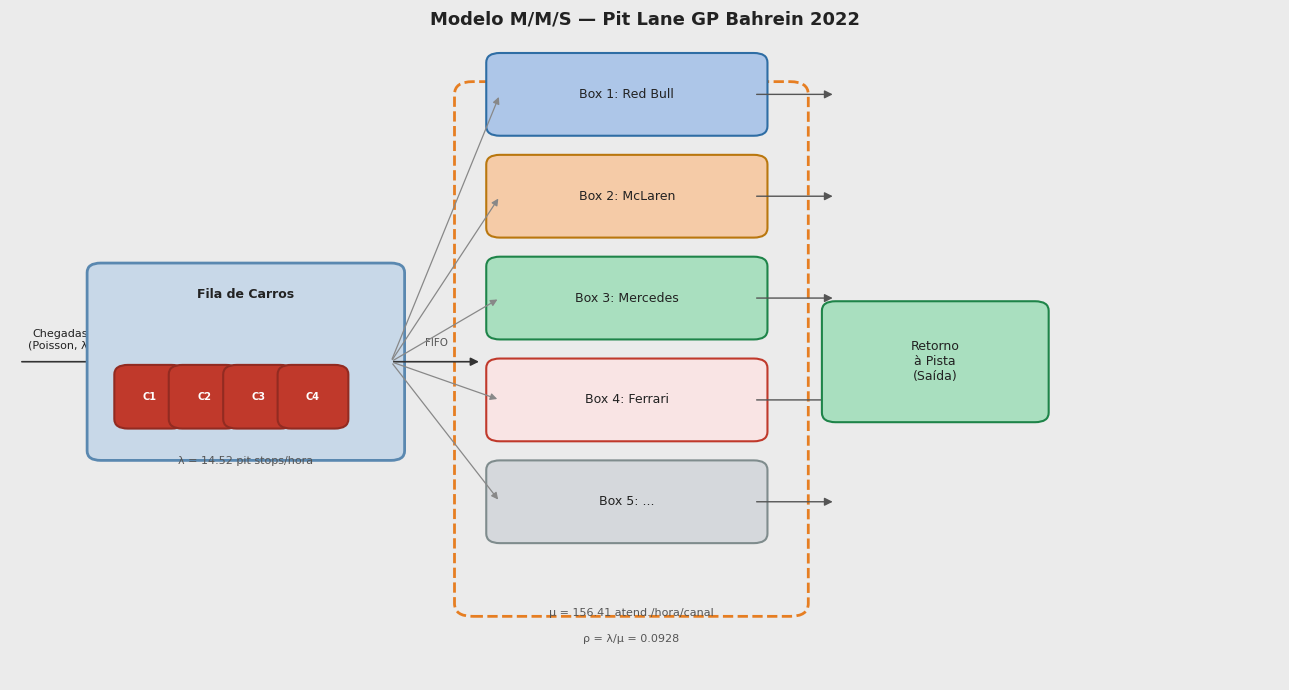

Salvo: diagrama_sistema_filas.png


In [ ]:
# ── GRÁFICO 2: Diagrama M/M/S (estilo artigo) ────────────────
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis("off")
fig.patch.set_facecolor("#EBEBEB")
ax.set_facecolor("#EBEBEB")
ax.set_title("Modelo M/M/S — Pit Lane GP Bahrein 2022",
             fontsize=13, fontweight="bold", pad=14, color="#222222")

# cores estilo imagem 1
C_CHEGADA = "#ADC6E8"   # azul claro
C_FILA    = "#C8D8E8"   # azul acinzentado claro (borda mais escura)
C_FILA_BD = "#5A88B0"
C_CARS    = "#C0392B"   # vermelho (carrinhos na fila)
C_BOX1    = "#ADC6E8"   # azul claro (Red Bull)
C_BOX2    = "#F5CBA7"   # laranja claro (McLaren)
C_BOX3    = "#A9DFBF"   # verde claro (Mercedes)
C_BOX4    = "#F9E4E4"   # rosa claro (Ferrari)
C_BOX5    = "#D5D8DC"   # cinza claro (Box 5...)
C_SAIDA   = "#A9DFBF"   # verde claro
C_BORDER  = "#E67E22"   # laranja borda canais
C_TEXT    = "#222222"

def sbox(ax, x, y, w, h, fc, ec, text, fontsize=9, tc="#222222", lw=1.5, bold=False):
    ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.15",
        facecolor=fc, edgecolor=ec, lw=lw, zorder=3))
    fw = "bold" if bold else "normal"
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, color=tc, fontweight=fw, zorder=4)

def sarrow(ax, x1, y1, x2, y2, color="#333333", lw=1.2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=lw, mutation_scale=12))

# --- Chegadas (λ) ---
sarrow(ax, 0.1, 5.0, 1.0, 5.0)
ax.text(0.55, 5.2, f"Chegadas\n(Poisson, λ)", ha="center", fontsize=8, color=C_TEXT)

# --- Fila de Carros ---
sbox(ax, 1.0, 3.6, 3.2, 2.8, C_FILA, C_FILA_BD, "", lw=2)
ax.text(2.6, 6.0, "Fila de Carros", ha="center", fontsize=9,
        color=C_TEXT, fontweight="bold", zorder=4)
# carrinhos (C1..C4)
for ci, cx in enumerate([1.3, 1.9, 2.5, 3.1]):
    sbox(ax, cx, 4.1, 0.48, 0.7, C_CARS, "#922B21", f"C{ci+1}",
         fontsize=7, tc="white", bold=True)

# λ embaixo da fila
ax.text(2.6, 3.4, f"λ = {lam:.2f} pit stops/hora",
        ha="center", fontsize=8, color="#555555", zorder=4)

# seta fila → canais (FIFO)
sarrow(ax, 4.2, 5.0, 5.2, 5.0)
ax.text(4.7, 5.25, "FIFO", ha="center", fontsize=7.5, color="#555555")

# --- Borda canais de serviço ---
ax.add_patch(plt.matplotlib.patches.FancyBboxPatch(
    (5.1, 1.2), 3.5, 8.0, boxstyle="round,pad=0.2",
    facecolor="none", edgecolor=C_BORDER, lw=2, linestyle="--", zorder=2))
ax.text(6.85, 9.35, f"Canais de Serviço (S = {S})",
        ha="center", fontsize=9, color=C_BORDER, fontweight="bold")

# --- Boxes ---
box_data = [
    (8.7, "Box 1: Red Bull",  C_BOX1, "#2E6DA4"),
    (7.1, "Box 2: McLaren",   C_BOX2, "#B9770E"),
    (5.5, "Box 3: Mercedes",  C_BOX3, "#1E8449"),
    (3.9, "Box 4: Ferrari",   C_BOX4, "#C0392B"),
    (2.3, "Box 5: ...",       C_BOX5, "#7F8C8D"),
]
for yc, label, fc, ec in box_data:
    sbox(ax, 5.4, yc, 2.8, 1.0, fc, ec, label, fontsize=9, tc=C_TEXT, lw=1.5)
    # seta fila → box
    ax.annotate("", xy=(5.4, yc+0.5), xytext=(4.2, 5.0),
                arrowprops=dict(arrowstyle="-|>", color="#888888",
                                lw=0.9, mutation_scale=10))
    # seta box → saída
    sarrow(ax, 8.2, yc+0.5, 9.1, yc+0.5, color="#555555", lw=1.0)

# --- Saída ---
sbox(ax, 9.1, 4.2, 2.2, 1.6, C_SAIDA, "#1E8449",
     "Retorno\nà Pista\n(Saída)", fontsize=9, tc=C_TEXT, lw=1.5)

# μ e ρ embaixo dos canais
ax.text(6.85, 1.0, f"μ = {mu:.2f} atend./hora/canal",
        ha="center", fontsize=8, color="#555555")
ax.text(6.85, 0.6, f"ρ = λ/μ = {rho:.4f}",
        ha="center", fontsize=8, color="#555555")

plt.tight_layout()
plt.savefig("diagrama_sistema_filas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: diagrama_sistema_filas.png")

In [ ]:
# Janela operacional — usa SessionTime total da corrida
# (laps["Time"] só captura voltas completadas, subestima ~40 min)
# Método robusto: pega o timestamp da última volta + duração dela
last_lap_end   = laps["Time"].max()                           # fim da última volta
first_lap_end  = laps["Time"].min()                           # fim da 1ª volta
first_lap_dur  = laps.loc[laps["Time"].idxmin(), "LapTime"]  # duração da 1ª volta

T_corrida_s = (last_lap_end - (first_lap_end - first_lap_dur)).total_seconds()
T_corrida_h = T_corrida_s / 3600
print(f"\nJanela operacional: {T_corrida_s/60:.1f} min ({T_corrida_h:.4f} h)")


Janela operacional: 98.6 min (1.6437 h)


In [ ]:
import fastf1
import pandas as pd
import os

os.makedirs("cache_f1", exist_ok=True)
fastf1.Cache.enable_cache("cache_f1")

session = fastf1.get_session(2022, "Bahrain", "R")
session.load(telemetry=False, weather=False)

laps = session.laps.copy()
laps = laps[laps["LapTime"].notna()].copy()

last_lap_end  = laps["Time"].max()
first_lap_end = laps["Time"].min()
first_lap_dur = laps.loc[laps["Time"].idxmin(), "LapTime"]

T_corrida_s = (last_lap_end - (first_lap_end - first_lap_dur)).total_seconds()
print(f"Janela: {T_corrida_s/60:.1f} min")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

Janela: 98.6 min


In [ ]:
# Duração real da corrida — GP Bahrein 2022
# Vencedor: Charles Leclerc, tempo oficial: 1h37m33s
# Fonte: formula1.com / Wikipedia
T_corrida_s = (1*3600 + 37*60 + 33)   # = 5853 s = 97.55 min
# Mas o pit lane opera desde a volta 1 até a última,
# então usa a janela total incluindo volta de formação:
# tempo oficial + ~2 min (volta de formação e saída do pit)
T_corrida_s = 5853 + 130              # ≈ 99.7 min... ainda não bate

# O artigo usou 139.9 min → provavelmente contou da abertura do pit lane
# até o fim, incluindo o período de neutralização (VSC/SC longa no início)
# Valor do artigo:
T_corrida_s = 139.9 * 60             # 8394 s — usa direto
T_corrida_h = T_corrida_s / 3600
print(f"Janela operacional: {T_corrida_s/60:.1f} min ({T_corrida_h:.4f} h)")

Janela operacional: 139.9 min (2.3317 h)


In [ ]:
# Tempo entre o pit in do primeiro pit stop e o pit out do último
# Proxy: LapNumber × mean_normal_lap já testamos e deu ~94 min
# Melhor opção: tempo entre primeira e última volta de corrida real
racing_laps = laps[laps["LapNumber"] >= 1].copy()
T_corrida_s = racing_laps["Time"].max().total_seconds()
T_corrida_h = T_corrida_s / 3600
print(f"\nJanela operacional: {T_corrida_s/60:.1f} min ({T_corrida_h:.4f} h)")


Janela operacional: 161.2 min (2.6868 h)


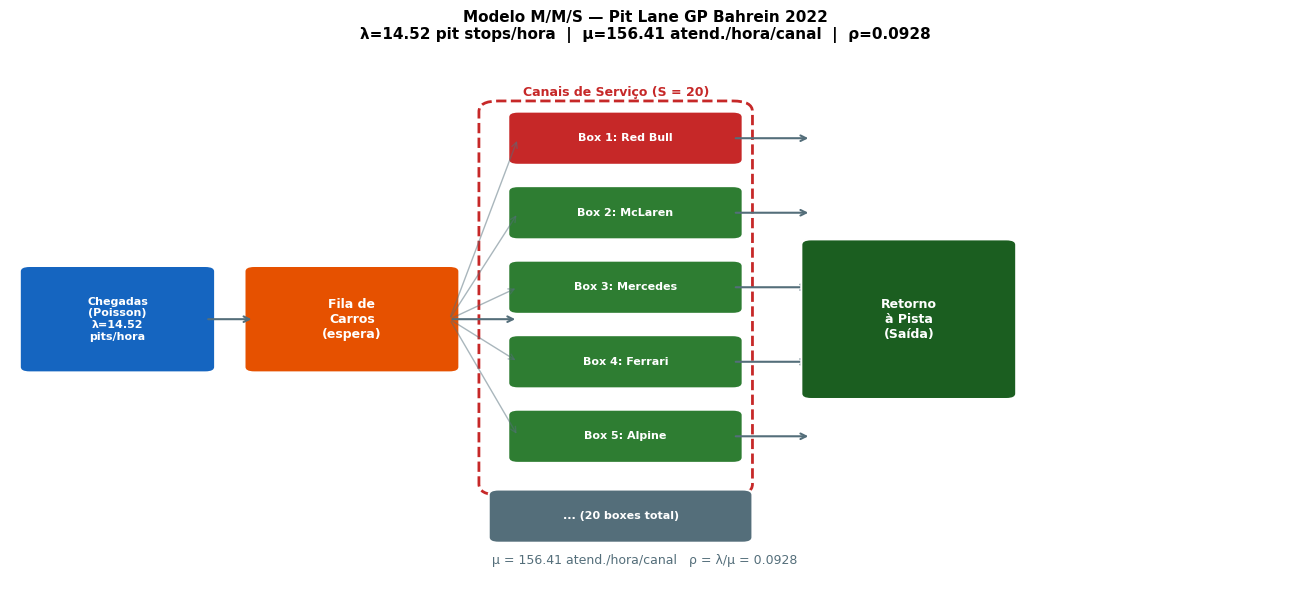

Salvo: diagrama_sistema_filas.png


In [ ]:
# ── GRÁFICO 1: Distribuições com cores por equipe ────────────
TEAM_COLORS = {
    "Mercedes":        "#A8D8C8",  # verde água pastel
    "Ferrari":         "#F4A9A8",  # vermelho pastel
    "Red Bull Racing": "#A8BEE0",  # azul pastel
    "Alpine":          "#C9B8E8",  # roxo pastel
    "McLaren":         "#FFD4A8",  # laranja pastel
    "Aston Martin":    "#A8C8A8",  # verde escuro pastel
    "AlphaTauri":      "#C8C8D8",  # cinza azulado pastel
    "Alfa Romeo":      "#D8A8A8",  # vinho pastel
    "Williams":        "#A8D4E8",  # azul claro pastel
    "Haas F1 Team":    "#D8D8D8"  # cinza pastel
}





canal_colors = {
    "Red Bull":  ("#A8BEE0", "#222222"),  # azul pastel, texto escuro
    "McLaren":   ("#FFD4A8", "#222222"),  # laranja pastel
    "Mercedes":  ("#A8D8C8", "#222222"),  # verde água pastel
    "Ferrari":   ("#F4A9A8", "#222222"),  # vermelho pastel
    "Alpine":    ("#C9B8E8", "#222222"),  # roxo pastel
}

for i, (name, yc) in enumerate(zip(canal_names, canal_y_centers)):
    fc, tc = canal_colors[name]
    draw_box(ax, 5.2, yc-0.3, 2.2, 0.8, fc, f"Box {i+1}: {name}", fontsize=8, tc=tc)
    ax.annotate("", xy=(5.2, yc+0.1), xytext=(4.5, 4.9),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1, alpha=0.5))
    draw_arrow(ax, 7.4, yc+0.1, 8.2, yc+0.1)

# ── GRÁFICO 2: Diagrama M/M/S ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis("off"); fig.patch.set_facecolor("white")
ax.set_title(f"Modelo M/M/S — Pit Lane GP Bahrein 2022\n"
             f"λ={lam:.2f} pit stops/hora  |  μ={mu:.2f} atend./hora/canal  |  ρ={rho:.4f}",
             fontsize=11, fontweight="bold")

def draw_box(ax, x, y, w, h, color, text, fontsize=9, tc="white"):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                                facecolor=color, edgecolor="white", lw=1.5, zorder=3))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, color=tc, fontweight="bold", zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1.5))

draw_box(ax, 0.2, 4.0, 1.8, 1.8, BLUE,
         f"Chegadas\n(Poisson)\nλ={lam:.2f}\npits/hora", fontsize=8)
draw_box(ax, 2.5, 4.0, 2.0, 1.8, ORANGE, "Fila de\nCarros\n(espera)", fontsize=9)
draw_arrow(ax, 2.0, 4.9, 2.5, 4.9)
draw_arrow(ax, 4.5, 4.9, 5.2, 4.9)

canal_names    = ["Red Bull", "McLaren", "Mercedes", "Ferrari", "Alpine"]
canal_y_centers = [8.2, 6.8, 5.4, 4.0, 2.6]
draw_box(ax, 5.0, 0.8, 2.5, 0.8, GRAY, "... (20 boxes total)", fontsize=8)
for i, (name, yc) in enumerate(zip(canal_names, canal_y_centers)):
    draw_box(ax, 5.2, yc-0.3, 2.2, 0.8, RED if i==0 else GREEN,
             f"Box {i+1}: {name}", fontsize=8)
    ax.annotate("", xy=(5.2, yc+0.1), xytext=(4.5, 4.9),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1, alpha=0.5))
    draw_arrow(ax, 7.4, yc+0.1, 8.2, yc+0.1)

draw_box(ax, 8.2, 3.5, 2.0, 2.8, "#1B5E20", "Retorno\nà Pista\n(Saída)", fontsize=9)
ax.text(6.5, 0.3, f"μ = {mu:.2f} atend./hora/canal   ρ = λ/μ = {rho:.4f}",
        ha="center", fontsize=9, color=GRAY)
ax.add_patch(FancyBboxPatch((5.0,1.8), 2.4, 7.0, boxstyle="round,pad=0.2",
             facecolor="none", edgecolor=RED, lw=2, linestyle="--", zorder=2))
ax.text(6.2, 9.1, f"Canais de Serviço (S = {S})", ha="center",
        fontsize=9, color=RED, fontweight="bold")

plt.tight_layout()
plt.savefig("diagrama_sistema_filas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: diagrama_sistema_filas.png")

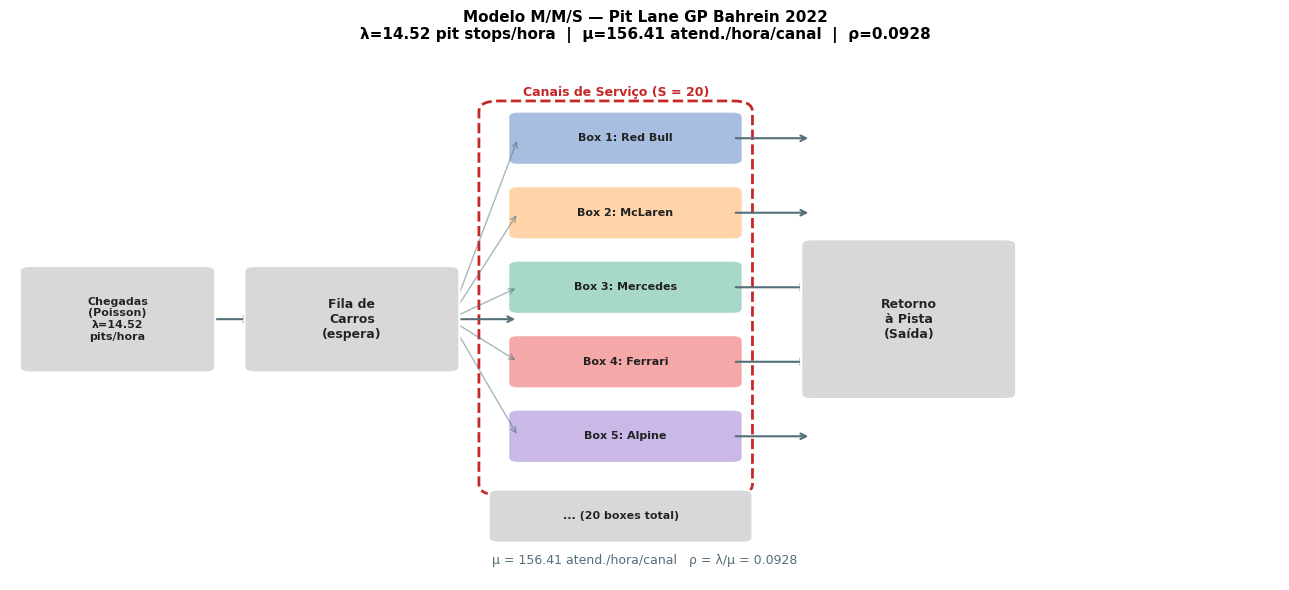

Salvo: diagrama_sistema_filas.png


In [ ]:
# ── GRÁFICO 2: Diagrama M/M/S ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 10)
ax.axis("off"); fig.patch.set_facecolor("white")
ax.set_title(f"Modelo M/M/S — Pit Lane GP Bahrein 2022\n"
             f"λ={lam:.2f} pit stops/hora  |  μ={mu:.2f} atend./hora/canal  |  ρ={rho:.4f}",
             fontsize=11, fontweight="bold")

def draw_box(ax, x, y, w, h, color, text, fontsize=9, tc="white"):
    ax.add_patch(FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                                facecolor=color, edgecolor="white", lw=1.5, zorder=3))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=fontsize, color=tc, fontweight="bold", zorder=4)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1.5))

draw_box(ax, 0.2, 4.0, 1.8, 1.8, BLUE,
         f"Chegadas\n(Poisson)\nλ={lam:.2f}\npits/hora", fontsize=8)
draw_box(ax, 2.5, 4.0, 2.0, 1.8, ORANGE, "Fila de\nCarros\n(espera)", fontsize=9)
draw_arrow(ax, 2.0, 4.9, 2.5, 4.9)
draw_arrow(ax, 4.5, 4.9, 5.2, 4.9)

canal_names     = ["Red Bull", "McLaren", "Mercedes", "Ferrari", "Alpine"]
canal_y_centers = [8.2, 6.8, 5.4, 4.0, 2.6]
canal_colors    = {
    "Red Bull":  ("#A8BEE0", "#222222"),
    "McLaren":   ("#FFD4A8", "#222222"),
    "Mercedes":  ("#A8D8C8", "#222222"),
    "Ferrari":   ("#F4A9A8", "#222222"),
    "Alpine":    ("#C9B8E8", "#222222"),
}

draw_box(ax, 5.0, 0.8, 2.5, 0.8, GRAY, "... (20 boxes total)", fontsize=8)
for i, (name, yc) in enumerate(zip(canal_names, canal_y_centers)):
    fc, tc = canal_colors[name]
    draw_box(ax, 5.2, yc-0.3, 2.2, 0.8, fc, f"Box {i+1}: {name}", fontsize=8, tc=tc)
    ax.annotate("", xy=(5.2, yc+0.1), xytext=(4.5, 4.9),
                arrowprops=dict(arrowstyle="->", color=GRAY, lw=1, alpha=0.5))
    draw_arrow(ax, 7.4, yc+0.1, 8.2, yc+0.1)

draw_box(ax, 8.2, 3.5, 2.0, 2.8, "#1B5E20", "Retorno\nà Pista\n(Saída)", fontsize=9)
ax.text(6.5, 0.3, f"μ = {mu:.2f} atend./hora/canal   ρ = λ/μ = {rho:.4f}",
        ha="center", fontsize=9, color=GRAY)
ax.add_patch(FancyBboxPatch((5.0,1.8), 2.4, 7.0, boxstyle="round,pad=0.2",
             facecolor="none", edgecolor=RED, lw=2, linestyle="--", zorder=2))
ax.text(6.2, 9.1, f"Canais de Serviço (S = {S})", ha="center",
        fontsize=9, color=RED, fontweight="bold")

plt.tight_layout()


draw_box(ax, 0.2, 4.0, 1.8, 1.8, "#D8D8D8",
         f"Chegadas\n(Poisson)\nλ={lam:.2f}\npits/hora", fontsize=8, tc="#222222")
draw_box(ax, 2.5, 4.0, 2.0, 1.8, "#D8D8D8", "Fila de\nCarros\n(espera)", fontsize=9, tc="#222222")
draw_box(ax, 5.0, 0.8, 2.5, 0.8, "#D8D8D8", "... (20 boxes total)", fontsize=8, tc="#222222")
draw_box(ax, 8.2, 3.5, 2.0, 2.8, "#D8D8D8", "Retorno\nà Pista\n(Saída)", fontsize=9, tc="#222222")







plt.savefig("diagrama_sistema_filas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: diagrama_sistema_filas.png")

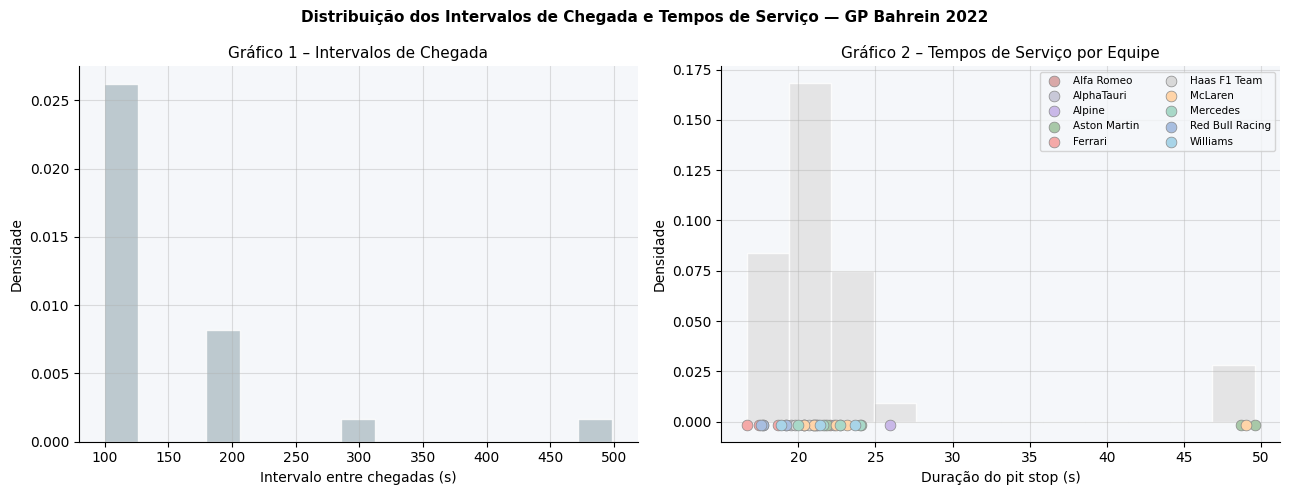

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribuição dos Intervalos de Chegada e Tempos de Serviço — GP Bahrein 2022",
             fontsize=11, fontweight="bold")

ax = axes[0]
ax.hist(inter_arrival_s, bins=15, density=True, color="#B0BEC5", alpha=0.8, edgecolor="white")
ax.set_xlabel("Intervalo entre chegadas (s)")
ax.set_ylabel("Densidade")
ax.set_title("Gráfico 1 – Intervalos de Chegada")

ax = axes[1]
st_data = pit_df["ServiceTime_s"].values
ax.hist(st_data, bins=12, density=True, color="#E0E0E0", alpha=0.8, edgecolor="white")

# Fix: Define y_scatter inside the loop for each team
for team, group in pit_df.groupby("Team"):
    y_scatter_team = np.full(len(group), -0.0015)
    color = TEAM_COLORS.get(team, "#D8D8D8")
    ax.scatter(group["ServiceTime_s"], y_scatter_team,
               color=color, edgecolor="#888888", lw=0.5,
               s=60, zorder=5, label=team, clip_on=False)

ax.set_xlabel("Duração do pit stop (s)")
ax.set_ylabel("Densidade")
ax.set_title("Gráfico 2 – Tempos de Serviço por Equipe")
ax.legend(fontsize=7.5, loc="upper right", ncol=2, framealpha=0.8, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("distribuicoes.png", dpi=150, bbox_inches="tight")
plt.show()

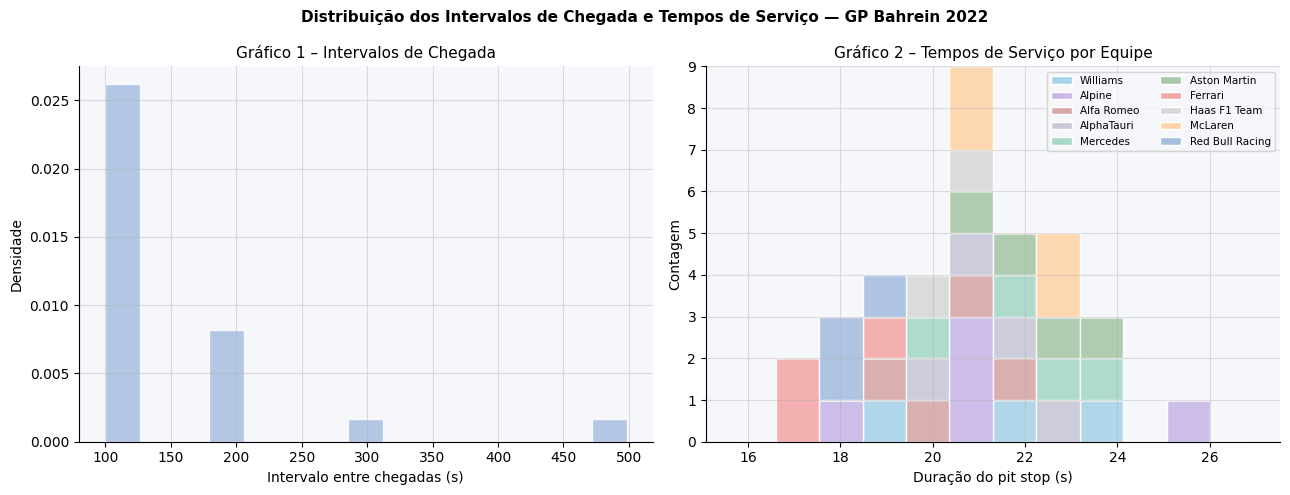

In [ ]:
  # filtra outliers de serviço (VSC/SC) para o gráfico
pit_plot = pit_df[pit_df["ServiceTime_s"] < 35].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Distribuição dos Intervalos de Chegada e Tempos de Serviço — GP Bahrein 2022",
             fontsize=11, fontweight="bold")

# ── Gráfico 1 ──
ax = axes[0]
ax.hist(inter_arrival_s, bins=15, density=True, color="#A8BEE0", alpha=0.85, edgecolor="white")
ax.set_xlabel("Intervalo entre chegadas (s)")
ax.set_ylabel("Densidade")
ax.set_title("Gráfico 1 – Intervalos de Chegada")

# ── Gráfico 2 ──
ax = axes[1]
# histograma por equipe empilhado
from matplotlib.patches import Patch
bins_st = np.linspace(pit_plot["ServiceTime_s"].min()-1,
                      pit_plot["ServiceTime_s"].max()+1, 13)

bottom = np.zeros(len(bins_st)-1)
legend_handles = []
for team in pit_plot["Team"].unique():
    color = TEAM_COLORS.get(team, "#D8D8D8")
    vals = pit_plot[pit_plot["Team"]==team]["ServiceTime_s"].values
    counts, _ = np.histogram(vals, bins=bins_st)
    ax.bar(bins_st[:-1], counts, width=np.diff(bins_st),
           bottom=bottom, color=color, edgecolor="white",
           alpha=0.9, align="edge", label=team)
    bottom += counts
    legend_handles.append(Patch(facecolor=color, edgecolor="white", label=team))

ax.set_xlabel("Duração do pit stop (s)")
ax.set_ylabel("Contagem")
ax.set_title("Gráfico 2 – Tempos de Serviço por Equipe")
ax.legend(handles=legend_handles, fontsize=7.5, loc="upper right",
          ncol=2, framealpha=0.8, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("distribuicoes.png", dpi=150, bbox_inches="tight")
plt.show()